In [ ]:
import pandas as pd
import sqlalchemy as sql
import h2o
from h2o.automl import H2OAutoML

In [ ]:
sql_engine = sql.create_engine("sqlite:///database/leads_scored.db")
conn = sql_engine.connect()

In [ ]:
metadata = sql.MetaData()
metadata.reflect(bind=sql_engine)
print(metadata.tables.keys())

dict_keys(['leads', 'leads_scored', 'message_store', 'products', 'transactions'])


In [ ]:
list(metadata.tables.keys())

['leads', 'leads_scored', 'message_store', 'products', 'transactions']

In [ ]:
pd.read_sql_table('leads_scored', conn)

,mailchimp_id,user_full_name,user_email,member_rating,optin_time,country_code,made_purchase,optin_days,email_provider,predict,p0,p1
0,3,Garrick Langworth,garrick.langworth@gmail.com,2,2019-05-22,in,1,-589,gmail.com,0,0.966912,0.033088
1,4,Cordell Dickens,cordell.dickens@gmail.com,4,2018-11-19,other,1,-773,gmail.com,0,0.855837,0.144163
2,8,Inga Dach,inga.dach@gmail.com,2,2018-11-19,other,1,-773,gmail.com,0,0.972288,0.027712
3,10,Ferdinand Bergstrom,ferdinand.bergstrom@gmail.com,2,2020-03-20,co,1,-286,gmail.com,0,0.966377,0.033623
4,11,Justen Simonis,justen.simonis@gmail.com,2,2020-04-14,other,0,-261,gmail.com,0,0.986628,0.013372
...,...,...,...,...,...,...,...,...,...,...,...,...
19914,33405,Ms. Felicity Moore MD,ms.felicity.moore.md@gmail.com,2,2018-11-18,other,0,-774,gmail.com,0,0.983641,0.016359
19915,33406,Shirley Rowe,shirley.rowe@gmail.com,1,2019-03-12,br,0,-660,gmail.com,0,0.986909,0.013091
19916,33407,Jarrett Walker-Carroll,jarrett.walkercarroll@gmail.com,2,2019-09-09,in,0,-479,gmail.com,0,0.985164,0.014836
19917,33408,Tanja Herzog,tanja.herzog@gmail.com,2,2019-10-24,other,0,-434,gmail.com,0,0.984795,0.015205


In [ ]:
import pytimetk as tk

In [ ]:
pd.read_sql_table('leads_scored', conn).glimpse()

<class 'pandas.core.frame.DataFrame'>: 19919 rows of 12 columns
mailchimp_id:    int64             [3, 4, 8, 10, 11, 14, 18, 19, 20, 22, ...
user_full_name:  object            ['Garrick Langworth', 'Cordell Dicken ...
user_email:      object            ['garrick.langworth@gmail.com', 'cord ...
member_rating:   int64             [2, 4, 2, 2, 2, 2, 2, 2, 4, 2, 2, 2,  ...
optin_time:      datetime64[ns]    [Timestamp('2019-05-22 00:00:00'), Ti ...
country_code:    object            ['in', 'other', 'other', 'co', 'other ...
made_purchase:   int64             [1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,  ...
optin_days:      int64             [-589, -773, -773, -286, -261, -423,  ...
email_provider:  object            ['gmail.com', 'gmail.com', 'gmail.com ...
predict:         int64             [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,  ...
p0:              float64           [0.9669123888015748, 0.85583710670471 ...
p1:              float64           [0.0330875962972641, 0.14416290819644 ...


In [ ]:
leads_df = pd.read_sql_table('leads', conn)
products_df = pd.read_sql_table('products', conn)
transactions_df = pd.read_sql_table('transactions', conn)

In [ ]:
df = leads_df.drop(columns=['mailchimp_id', 'made_purchase', 'user_full_name'])

In [ ]:
target = transactions_df['user_email'].unique()

In [ ]:
target

array(['deliah.kemmer@gmail.com', 'dr.ronal.keeling.dvm@gmail.com',
       'taya.ondrickaorn@hotmail.com', 'camren.auer.dds@live.com',
       'dr.janna.glover.phd@gmail.com', 'kayson.franecki@hotmail.com',
       'juwan.ruecker@hotmail.com', 'garrick.langworth@gmail.com',
       'augustus.leffler@gmail.com', 'cordell.dickens@gmail.com',
       'dr.donta.conroy@gmail.com', 'mistie.nicolas@gmail.com',
       'junius.blanda@gmail.com', 'gladstone.crist@gmail.com',
       'elza.larson@gmail.com', 'greta.koepp.md@gmail.com',
       'kaelynn.stoltenberg@gmail.com', 'inga.dach@gmail.com',
       'jakob.oconnell@gmail.com', 'eloy.terry@gmail.com',
       'dr.deanne.turcotte@gmail.com', 'ferdinand.bergstrom@gmail.com',
       'justen.simonis@live.com', 'mr.claudius.lind.phd@gmail.com',
       'minna.schmitt@gmail.com', 'van.koelpin@gmail.com',
       'jeanie.pouros@gmail.com', 'myer.wolff.md@gmail.com',
       'marylou.zulauf@gmail.com', 'marion.corwin@gmail.com',
       'lethia.davishuels@outl

In [ ]:
leads_df = pd.read_sql_table('leads', conn)
products_df = pd.read_sql_table('products', conn)
transactions_df = pd.read_sql_table('transactions', conn)

# Drop unnecessary columns
df = leads_df.drop(columns=['mailchimp_id', 'made_purchase', 'user_full_name'])

# Create the target from buyer's email addresses
target = transactions_df['user_email'].unique()
df['purchased'] = df['user_email'].isin(target).astype(int)

In [ ]:
hf = h2o.H2OFrame(df)

H2OConnectionError: Not connected to a cluster. Did you run `h2o.init()` or `h2o.connect()`?

In [ ]:
hf['purchased'] = hf['purchased'].asfactor()

: 

In [ ]:
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "11.0.13" 2021-10-19; OpenJDK Runtime Environment JBR-11.0.13.7-1751.21-jcef (build 11.0.13+7-b1751.21); OpenJDK 64-Bit Server VM JBR-11.0.13.7-1751.21-jcef (build 11.0.13+7-b1751.21, mixed mode)
  Starting server from /Users/mdancho/opt/anaconda3/envs/ds4b_301p_dev/lib/python3.10/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /var/folders/st/s5vwv9pd27g7z2sffwlqmtv80000gn/T/tmp4_4p7e5x
  JVM stdout: /var/folders/st/s5vwv9pd27g7z2sffwlqmtv80000gn/T/tmp4_4p7e5x/h2o_mdancho_started_from_python.out
  JVM stderr: /var/folders/st/s5vwv9pd27g7z2sffwlqmtv80000gn/T/tmp4_4p7e5x/h2o_mdancho_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stabl

H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,America/New_York
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.1
H2O_cluster_version_age:,6 months and 27 days
H2O_cluster_name:,H2O_from_python_mdancho_zz8oka
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,8 Gb
H2O_cluster_total_cores:,12
H2O_cluster_allowed_cores:,12
H2O_cluster_status:,"locked, healthy"


In [ ]:
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,45 secs
H2O_cluster_timezone:,America/New_York
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.1
H2O_cluster_version_age:,6 months and 27 days
H2O_cluster_name:,H2O_from_python_mdancho_zz8oka
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,8 Gb
H2O_cluster_total_cores:,12
H2O_cluster_allowed_cores:,12
H2O_cluster_status:,"locked, healthy"


In [ ]:
hf = h2o.H2OFrame(df)

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [ ]:
hf['purchased'] = hf['purchased'].asfactor()

In [ ]:
predictors = [
 'member_rating',
 'optin_time',
 'country_code',
 'optin_days',
 'email_provider'
]
response = "purchased"

In [ ]:
automl = H2OAutoML(max_models=20, seed=1, max_runtime_secs=20)

In [ ]:
automl.train(x=predictors, y=response, training_frame=hf)

AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


Model Details
=============
H2OXGBoostEstimator : XGBoost
Model Key: XGBoost_1_AutoML_1_20241011_84239


Model Summary: 
    number_of_trees
--  -----------------
    43

ModelMetricsBinomial: xgboost
** Reported on train data. **

MSE: 0.039030693268248345
RMSE: 0.19756187200026312
LogLoss: 0.1501873479708773
Mean Per-Class Error: 0.31767624990445054
AUC: 0.8419287243468285
AUCPR: 0.31653881722228355
Gini: 0.683857448693657

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.1518703368694886
       0      1     Error    Rate
-----  -----  ----  -------  ----------------
0      18007  950   0.0501   (950.0/18957.0)
1      563    399   0.5852   (563.0/962.0)
Total  18570  1349  0.076    (1513.0/19919.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.15187      0.345305  171
max f2                       0.0999389    0.433503  222
max f0point5                 0.277424     0.381451  95
max accuracy                 0.362211     0.954466  60
max precision                0.851852     1         0
max recall                   0.00527501   1         395
max specificity              0.851852     1         0
max absolute_mcc             0.15187      0.311124  171
max min_per_class_accuracy   0.0519587    0.765575  284
max mean_per_class_accuracy  0.0502993    0.766124  287
max tns                      0.851852     18957     0
max fns                      0.851852     961       0
max fps                      0.000701111  18957     399
max tps                      0.00527501   962       395
max tnr                      0.851852     1         0
max fnr                      0.851852     0.99896   0
max fpr                      0.000701111  1         399
max tpr                      0.00527501   1         395

Gains/Lift Table: Avg response rate:  4.83 %, avg score:  4.81 %
group    cumulative_data_fraction    lower_threshold    lift       cumulative_lift    response_rate    score       cumulative_response_rate    cumulative_score    capture_rate    cumulative_capture_rate    gain      cumulative_gain    kolmogorov_smirnov
-------  --------------------------  -----------------  ---------  -----------------  ---------------  ----------  --------------------------  ------------------  --------------  -------------------------  --------  -----------------  --------------------
1        0.0100407                   0.345487           12.8376    12.8376            0.62             0.485109    0.62                        0.485109            0.128898        0.128898                   1183.76   1183.76            0.124889
2        0.0201817                   0.287457           7.17528    9.99236            0.346535         0.315397    0.482587                    0.399831            0.0727651       0.201663                   617.528   899.236            0.190691
3        0.0300718                   0.225165           5.88592    8.64183            0.284264         0.252048    0.417362                    0.351228            0.0582121       0.259875                   488.592   764.183            0.241465
4        0.0411165                   0.202039           4.61175    7.55927            0.222727         0.212706    0.365079                    0.314018            0.0509356       0.310811                   361.175   655.927            0.28338
5        0.0501531                   0.182535           3.45097    6.81903            0.166667         0.191381    0.329329                    0.291921            0.031185        0.341996                   245.097   581.903            0.306653
6        0.100055                    0.116203           3.3121     5.06997            0.15996          0.143532    0.244857                    0.217913            0.165281        0.507277                   231.21    406.997            0.427886
7        0.150008                    0.0907147          2.1018     4.081

In [ ]:
lb = automl.leaderboard

In [ ]:
print(lb)

model_id                                auc    logloss     aucpr    mean_per_class_error      rmse        mse
XGBoost_1_AutoML_1_20241011_84239  0.76911    0.169144  0.195964                0.37993   0.20646   0.0426259
GLM_1_AutoML_1_20241011_84239      0.754977   0.172416  0.154091                0.377514  0.208368  0.0434174
[2 rows x 7 columns]



In [ ]:
'best_model_h2o_' + str(automl.leader.model_id)

'best_model_h2o_XGBoost_1_AutoML_1_20241011_84239'

In [ ]:
h2o.save_model(
    automl.leader, 
    path = "models", 
    filename = 'best_model_h2o_' + str(automl.leader.model_id),
    force = True
)

'/Users/mdancho/Desktop/course_code/DS4B_301P_P2_DEV_SQL/models/best_model_h2o_XGBoost_1_AutoML_1_20241011_84239'

In [ ]:
best_model_h2o = h2o.load_model("models/best_model_h2o")

In [ ]:
best_model_h2o

Model Details
=============
H2OXGBoostEstimator : XGBoost
Model Key: XGBoost_3_AutoML_5_20240416_162642


Model Summary: 
    number_of_trees
--  -----------------
    48

ModelMetricsBinomial: xgboost
** Reported on train data. **

MSE: 0.03931276327621486
RMSE: 0.19827446450870786
LogLoss: 0.15178390150034254
Mean Per-Class Error: 0.33177155937877567
AUC: 0.8369092399397827
AUCPR: 0.3060612437491249
Gini: 0.6738184798795654

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.1679074615240097
       0      1     Error    Rate
-----  -----  ----  -------  ----------------
0      18182  775   0.0409   (775.0/18957.0)
1      599    363   0.6227   (599.0/962.0)
Total  18781  1138  0.069    (1374.0/19919.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.167907     0.345714  150
max f2                       0.0894384    0.42571   222
max f0point5                 0.254319     0.36425   97
max accuracy                 0.432277     0.954014  40
max precision                0.932674     1         0
max recall                   0.00278422   1         396
max specificity              0.932674     1         0
max absolute_mcc             0.167907     0.310793  150
max min_per_class_accuracy   0.0543916    0.762994  272
max mean_per_class_accuracy  0.0529876    0.764607  274
max tns                      0.932674     18957     0
max fns                      0.932674     960       0
max fps                      0.000515153  18957     399
max tps                      0.00278422   962       396
max tnr                      0.932674     1         0
max fnr                      0.932674     0.997921  0
max fpr                      0.000515153  1         399
max tpr                      0.00278422   1         396

Gains/Lift Table: Avg response rate:  4.83 %, avg score:  4.88 %
group    cumulative_data_fraction    lower_threshold    lift       cumulative_lift    response_rate    score       cumulative_response_rate    cumulative_score    capture_rate    cumulative_capture_rate    gain      cumulative_gain    kolmogorov_smirnov
-------  --------------------------  -----------------  ---------  -----------------  ---------------  ----------  --------------------------  ------------------  --------------  -------------------------  --------  -----------------  --------------------
1        0.0100407                   0.329428           12.1129    12.1129            0.585            0.470494    0.585                       0.470494            0.121622        0.121622                   1111.29   1111.29            0.117243
2        0.0200311                   0.277899           6.65916    9.39287            0.321608         0.307595    0.453634                    0.389249            0.0665281       0.18815                    565.916   839.287            0.17665
3        0.030122                    0.232157           5.66577    8.14429            0.273632         0.247232    0.393333                    0.341673            0.0571726       0.245322                   466.577   714.429            0.226121
4        0.0401627                   0.204044           5.07293    7.37645            0.245            0.217762    0.35625                     0.310695            0.0509356       0.296258                   407.293   637.645            0.269091
5        0.0500025                   0.17786            4.96517    6.90194            0.239796         0.189924    0.333333                    0.286929            0.0488565       0.345114                   396.517   590.194            0.310088
6        0.100055                    0.115687           3.05291    4.97646            0.147442         0.142506    0.240341                    0.214681            0.152807        0.497921                   205.291   397.646            0.418056
7        0.153371                    0.0854107          2.10568    3.97

In [ ]:
best_model_h2o.explain()

TypeError: explain() missing 1 required positional argument: 'frame'

# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## XGBoost_3_AutoML_5_20240416_162642

,0,1,Error,Rate
0,18182.0,775.0,0.0409,(775.0/18957.0)
1,599.0,363.0,0.6227,(599.0/962.0)
Total,18781.0,1138.0,0.069,(1374.0/19919.0)


# Learning Curve Plot

> Learning curve plot shows the loss function/metric dependent on number of iterations or trees for tree-based algorithms. This plot can be useful for determining whether the model overfits.

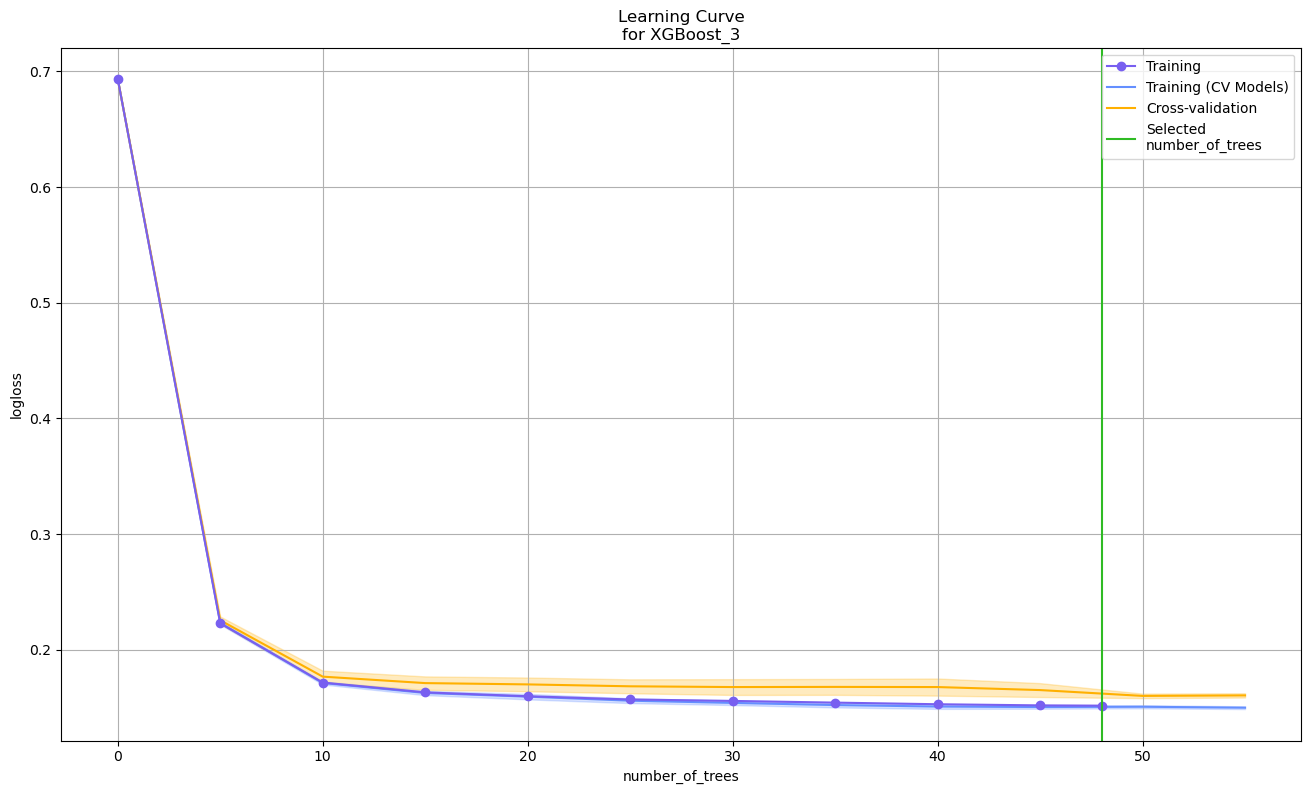

# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

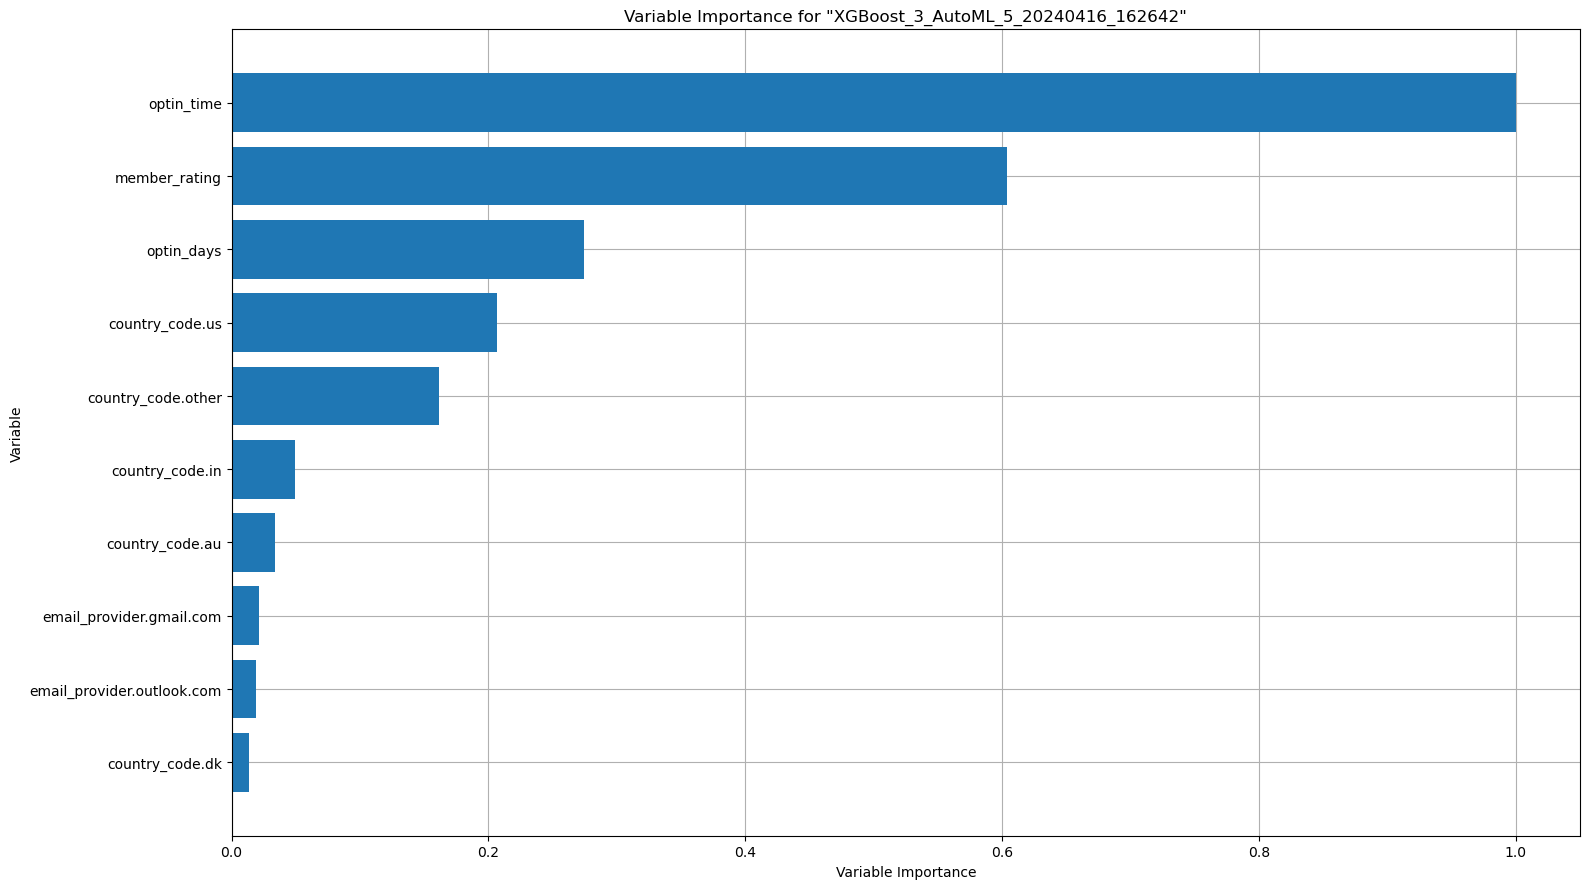

# SHAP Summary

> SHAP summary plot shows the contribution of the features for each instance (row of data). The sum of the feature contributions and the bias term is equal to the raw prediction of the model, i.e., prediction before applying inverse link function.

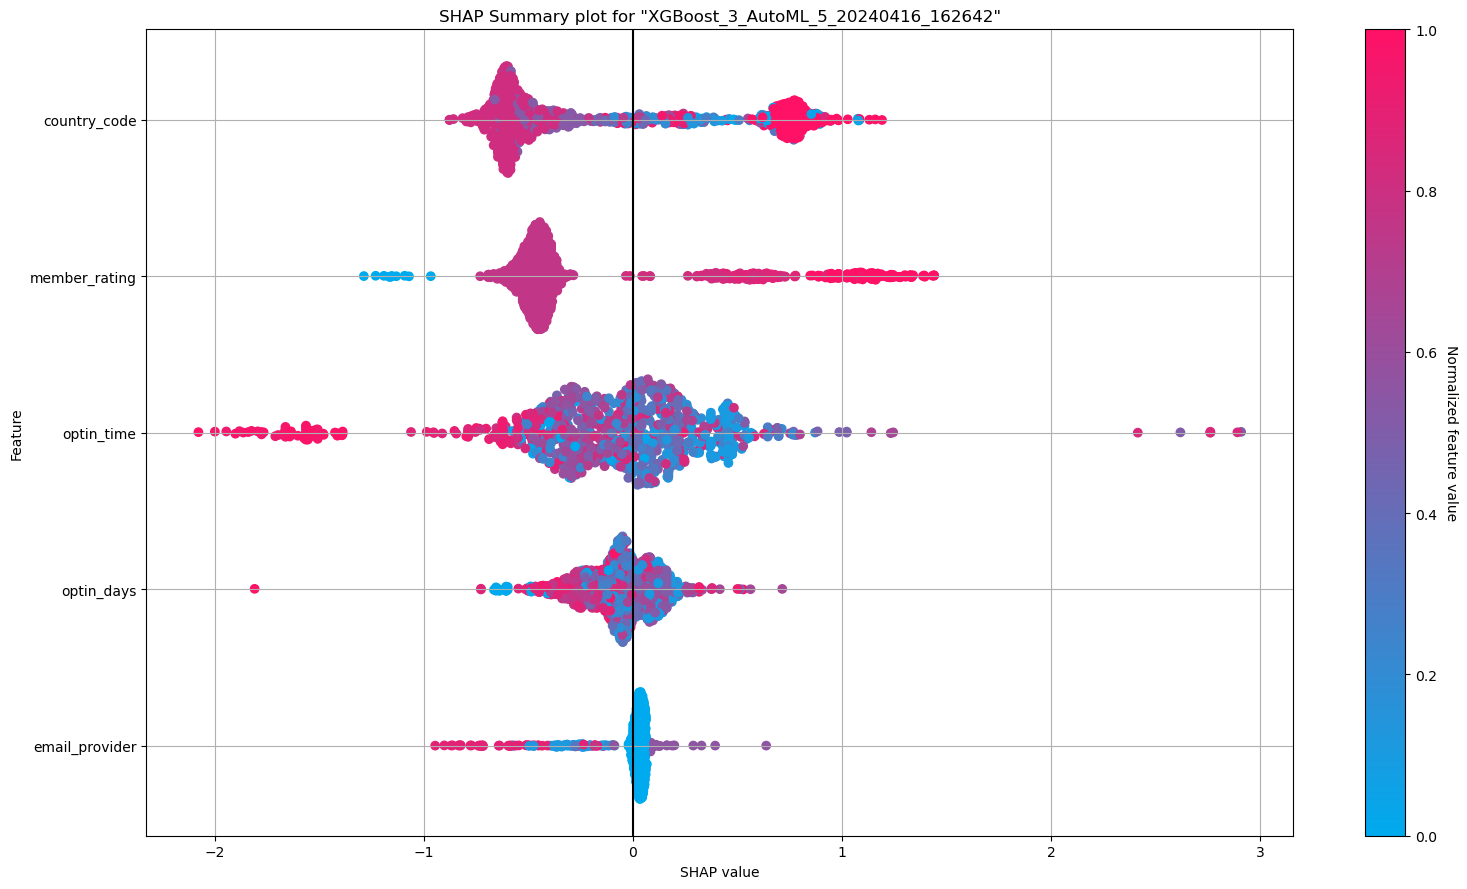

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

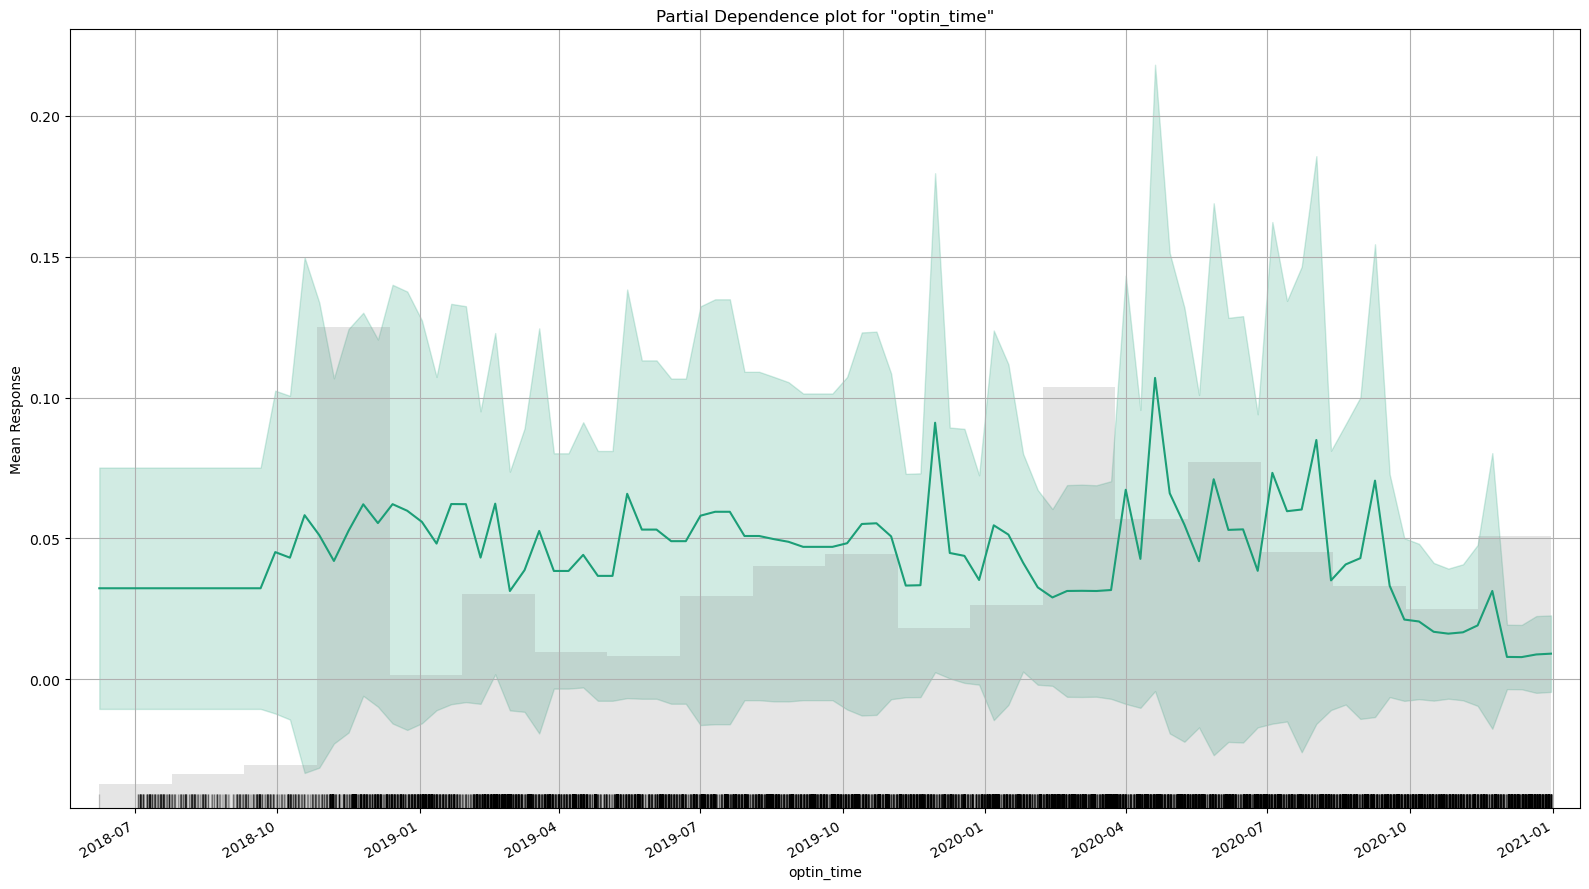

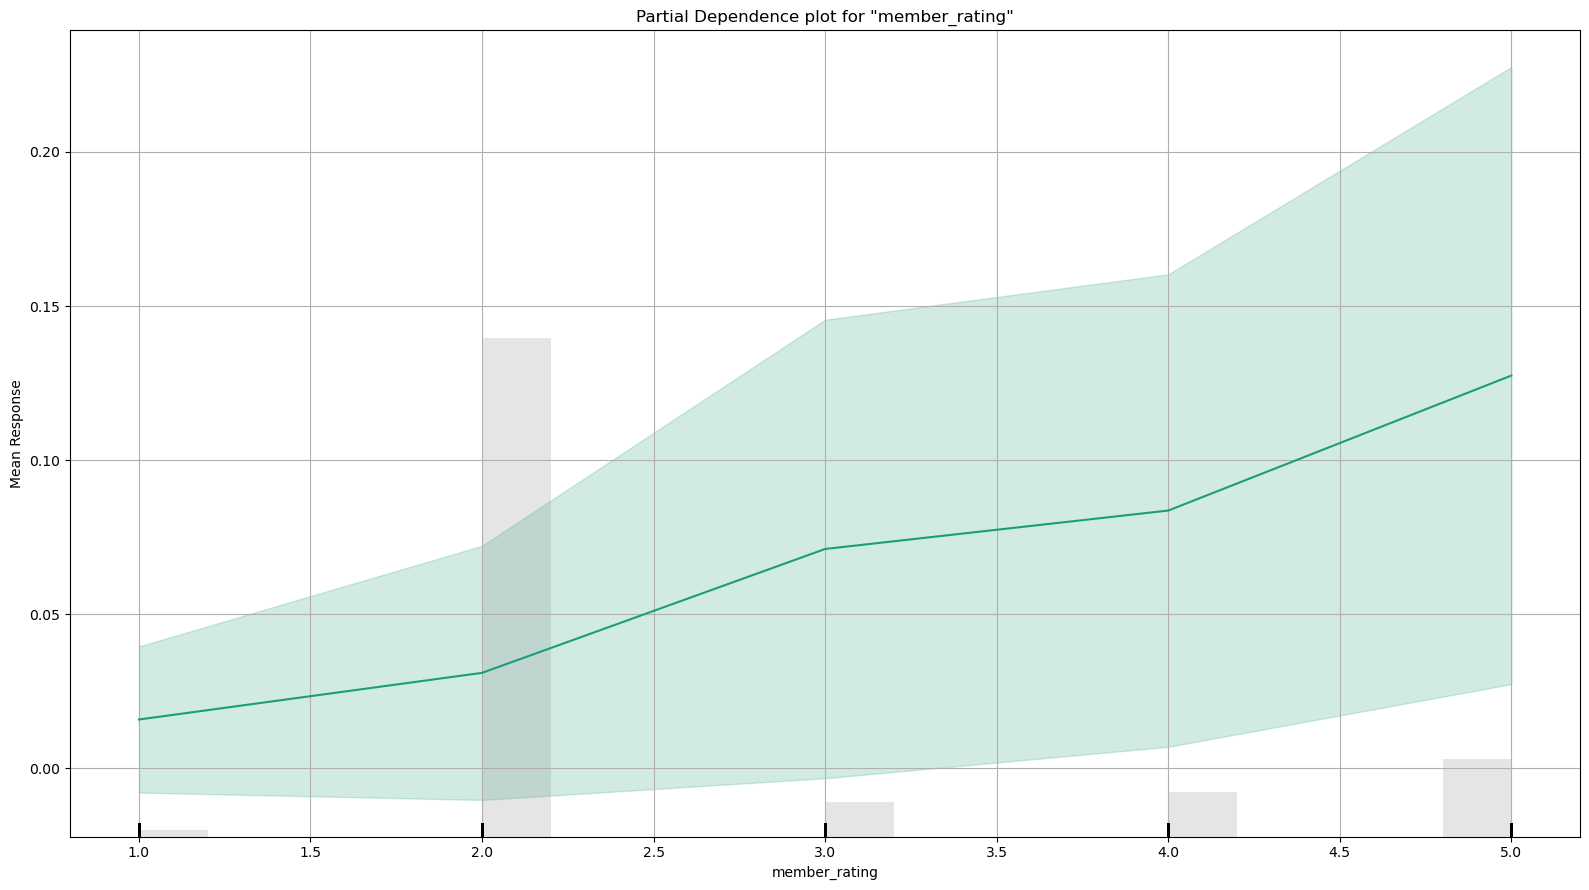

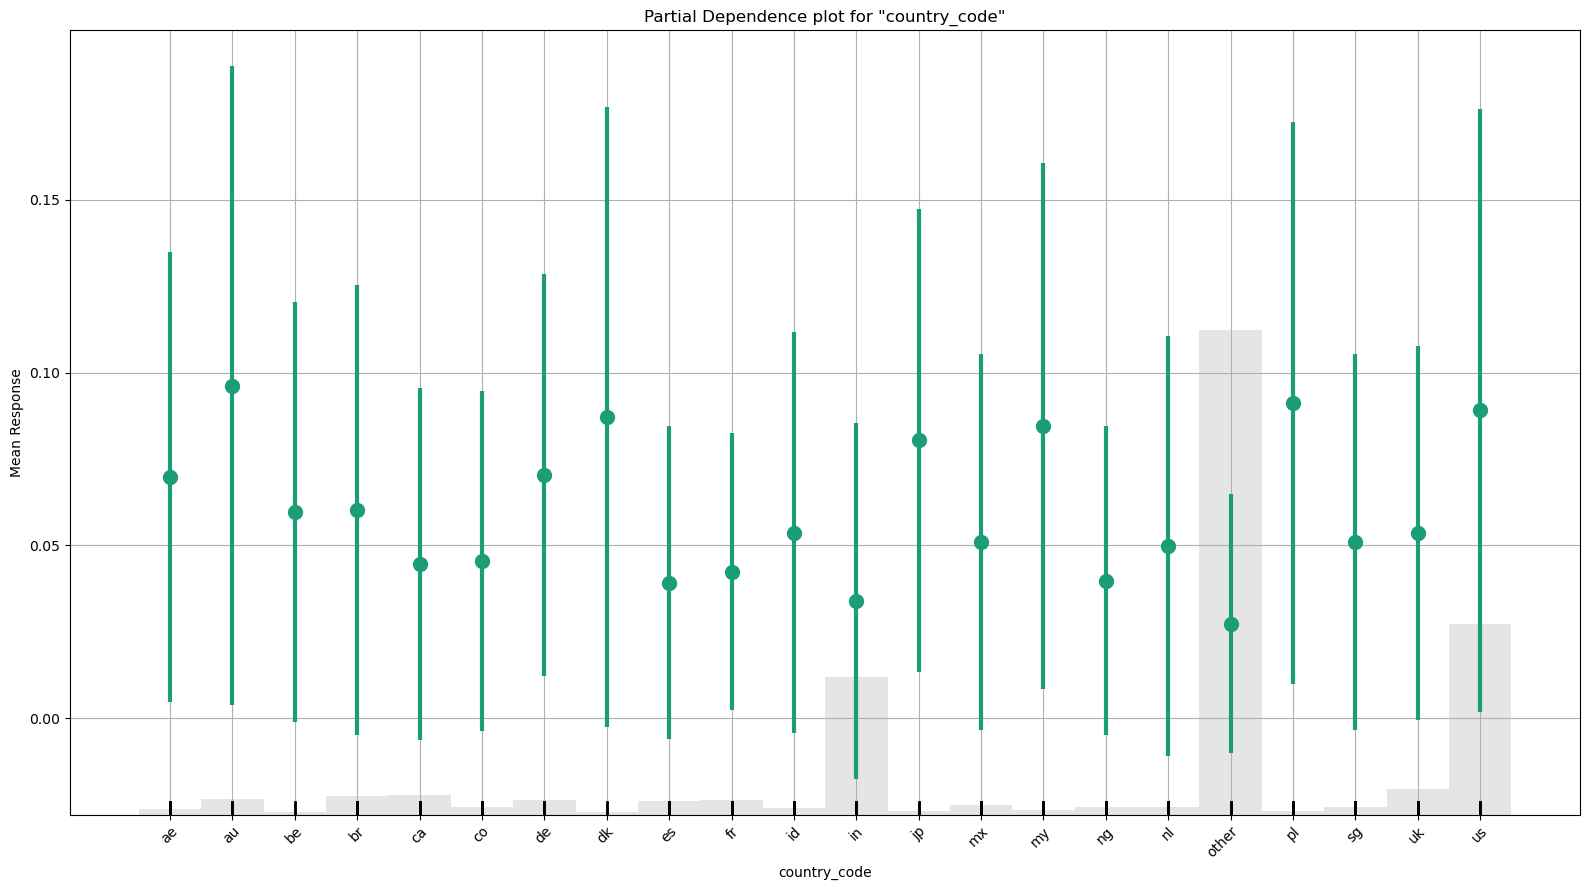

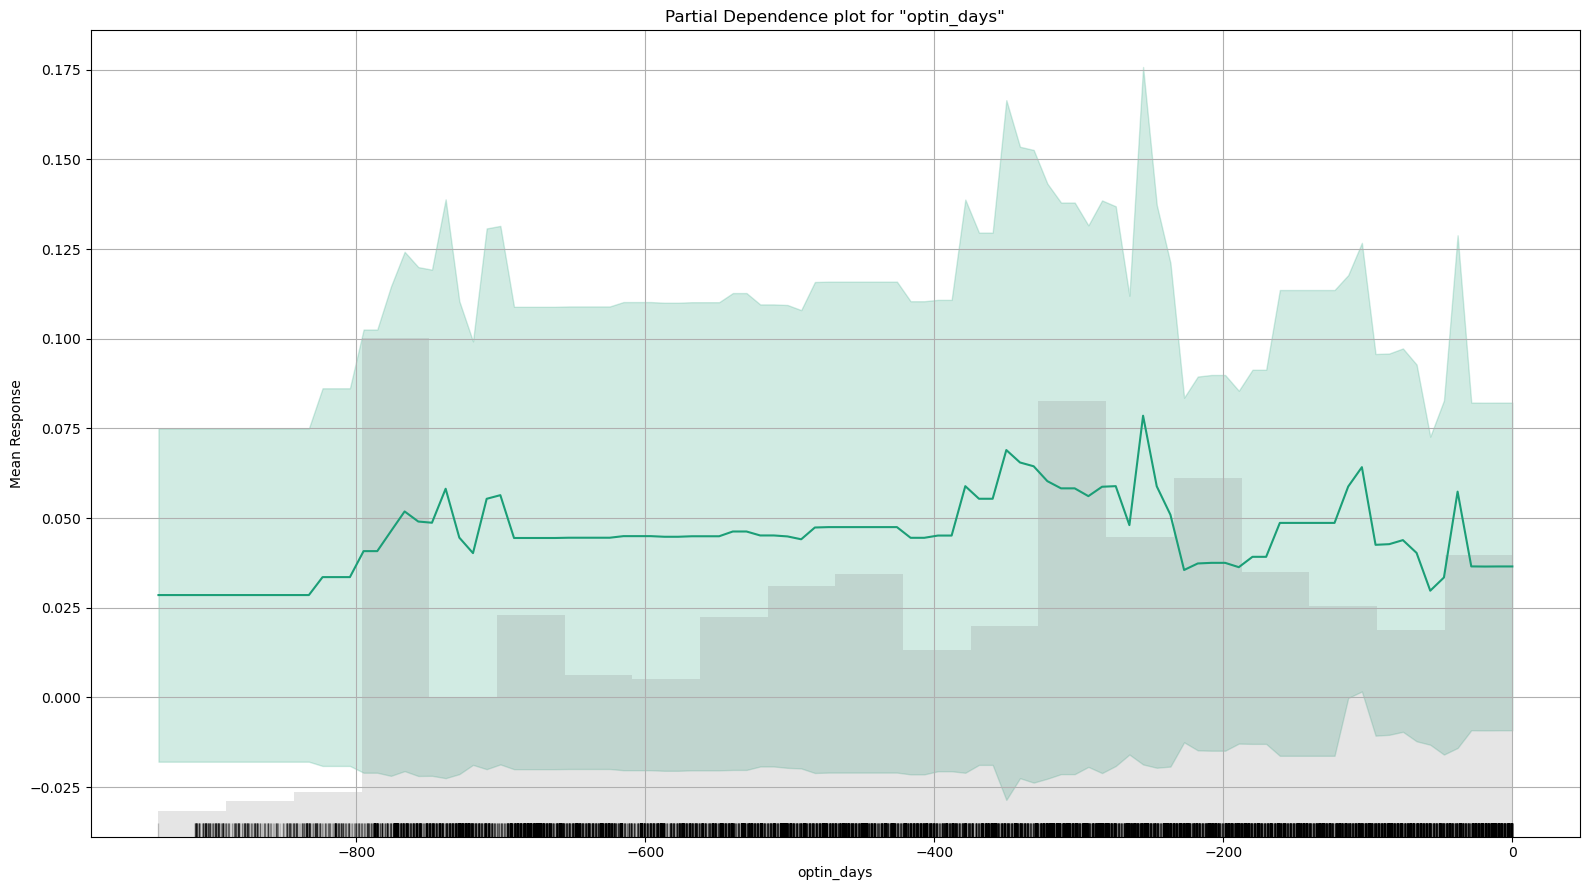

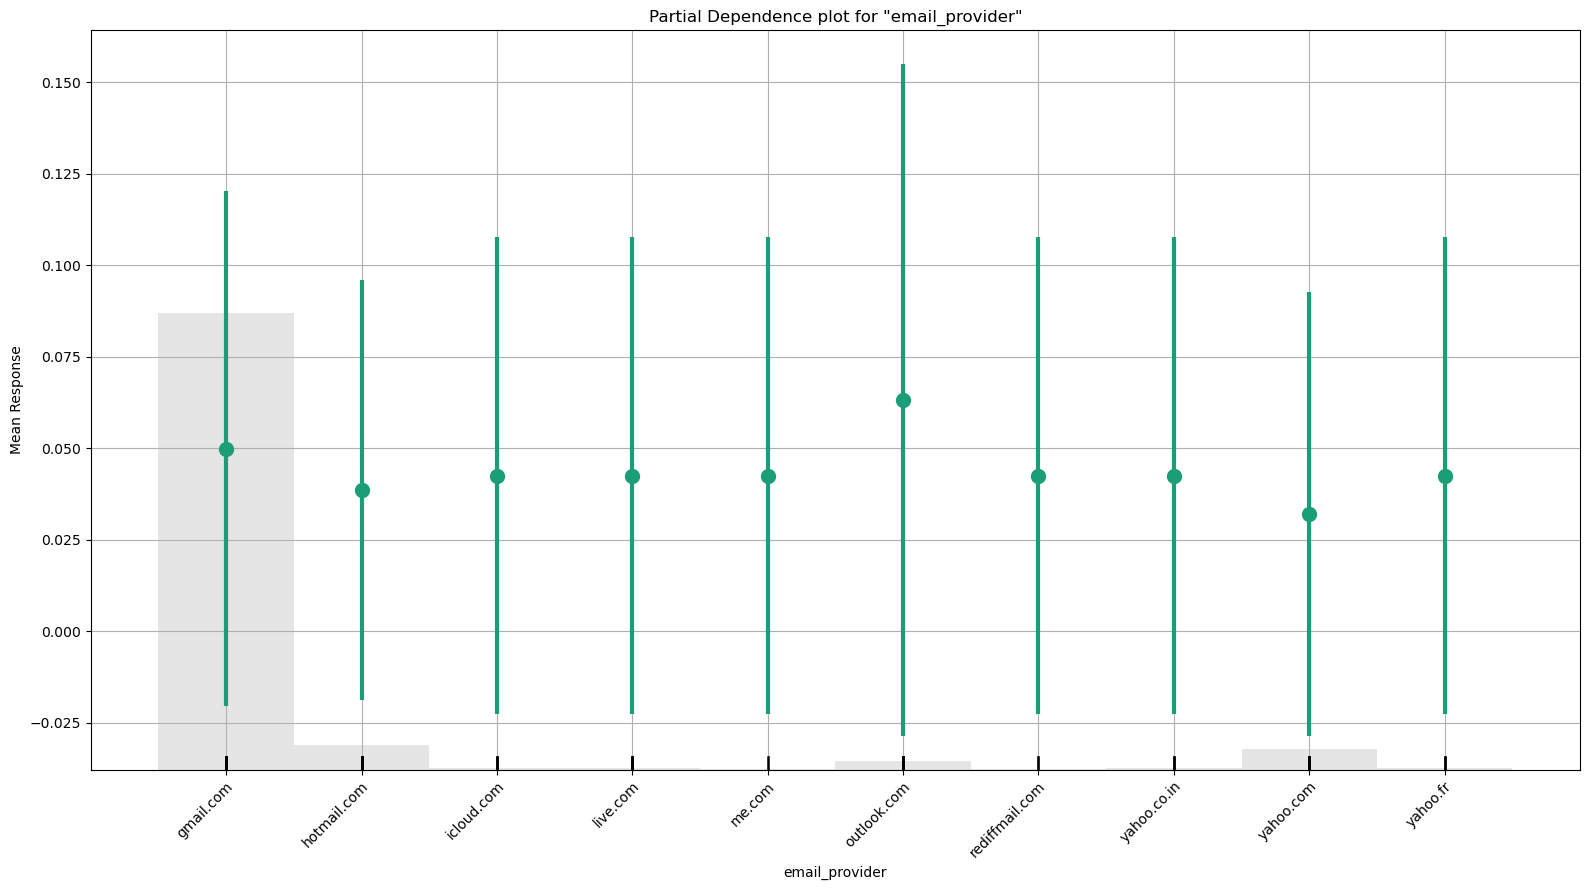

# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## XGBoost_3_AutoML_5_20240416_162642

,0,1,Error,Rate
0,18182.0,775.0,0.0409,(775.0/18957.0)
1,599.0,363.0,0.6227,(599.0/962.0)
Total,18781.0,1138.0,0.069,(1374.0/19919.0)


# Learning Curve Plot

> Learning curve plot shows the loss function/metric dependent on number of iterations or trees for tree-based algorithms. This plot can be useful for determining whether the model overfits.

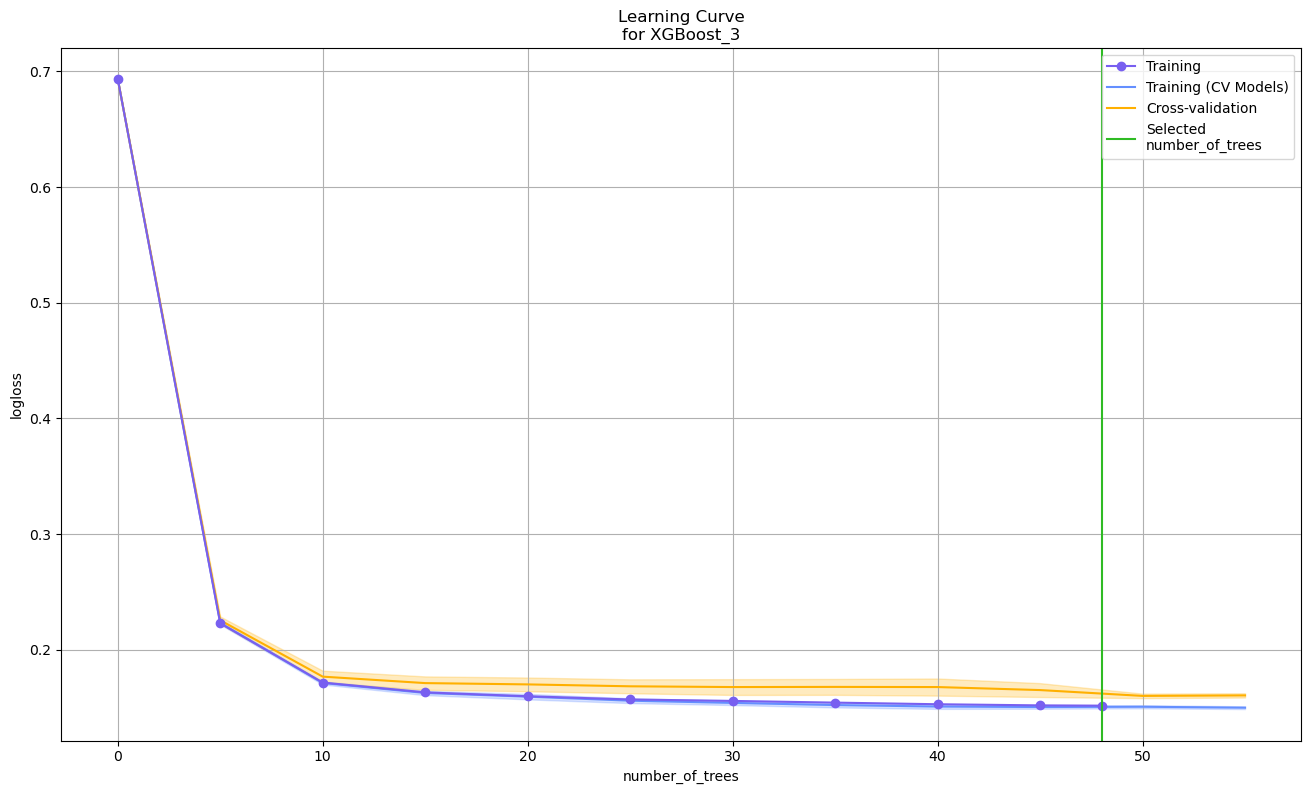

# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

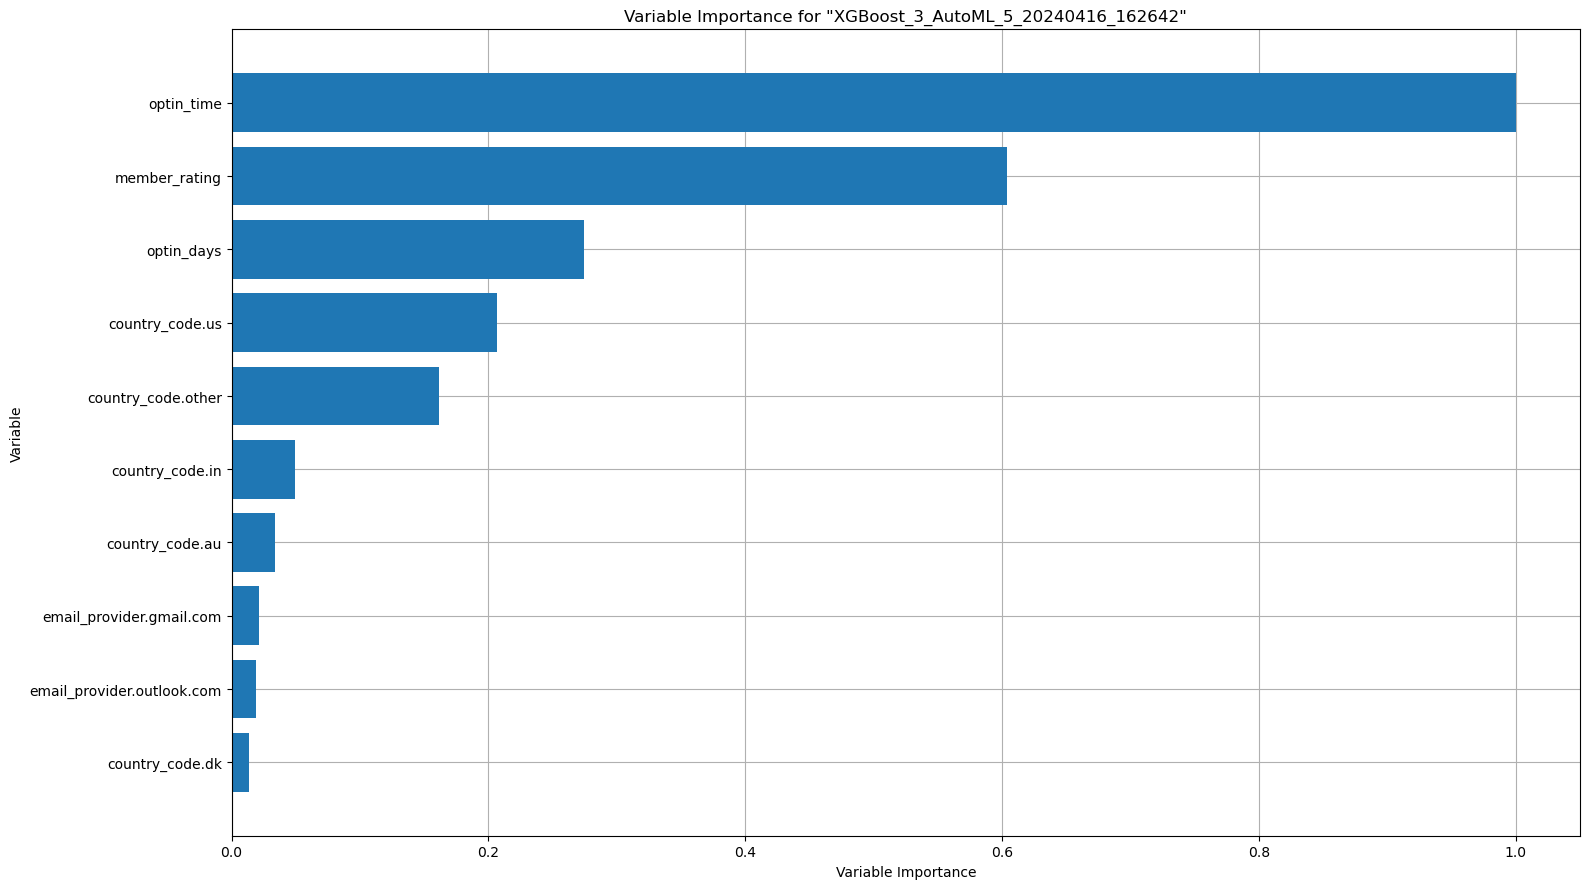

# SHAP Summary

> SHAP summary plot shows the contribution of the features for each instance (row of data). The sum of the feature contributions and the bias term is equal to the raw prediction of the model, i.e., prediction before applying inverse link function.

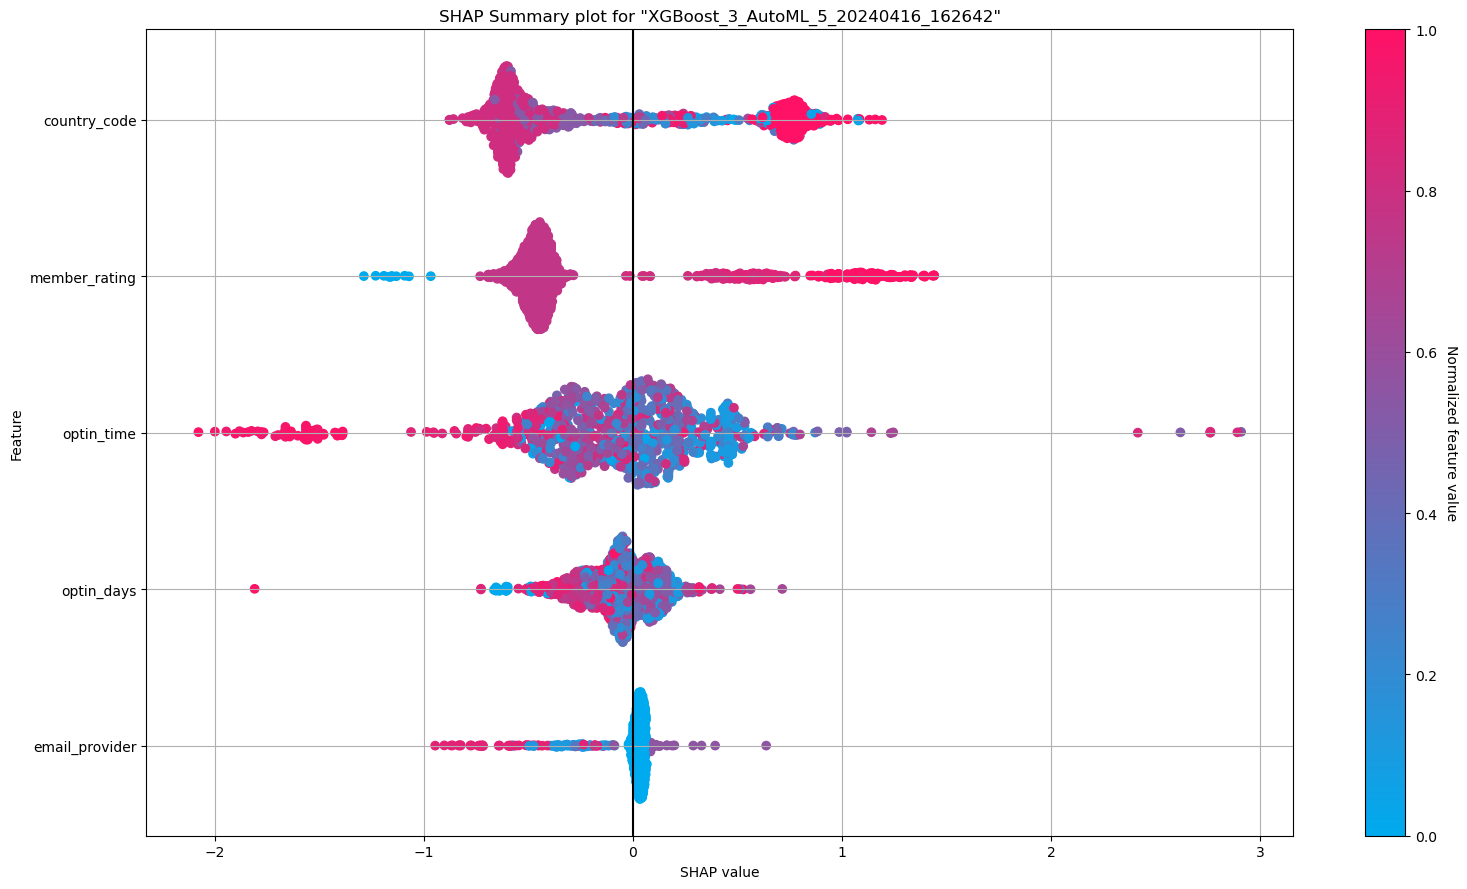

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

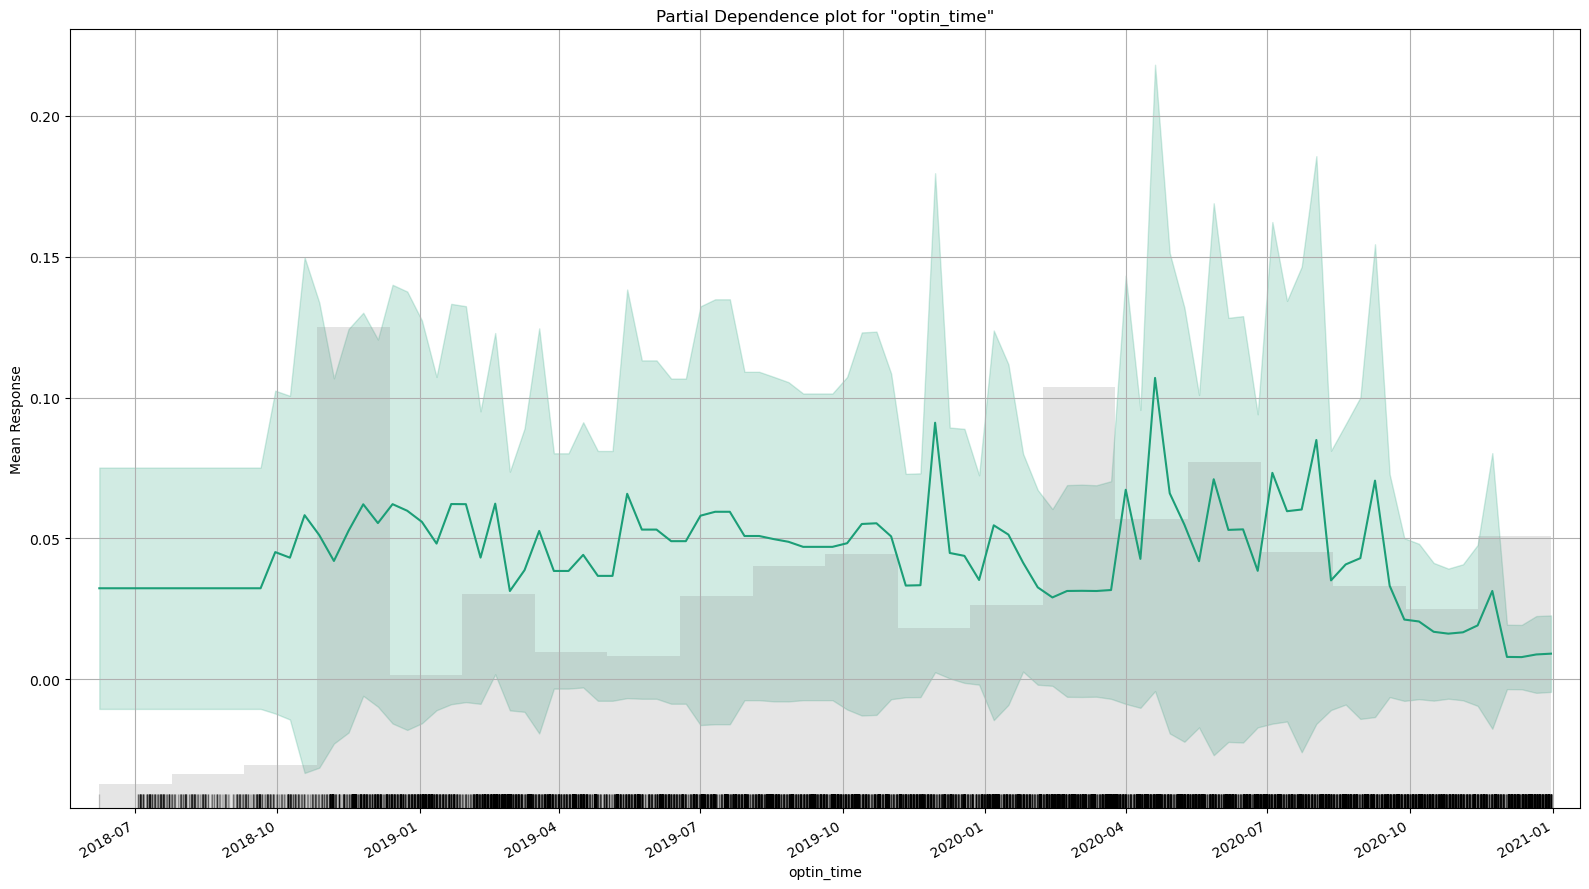

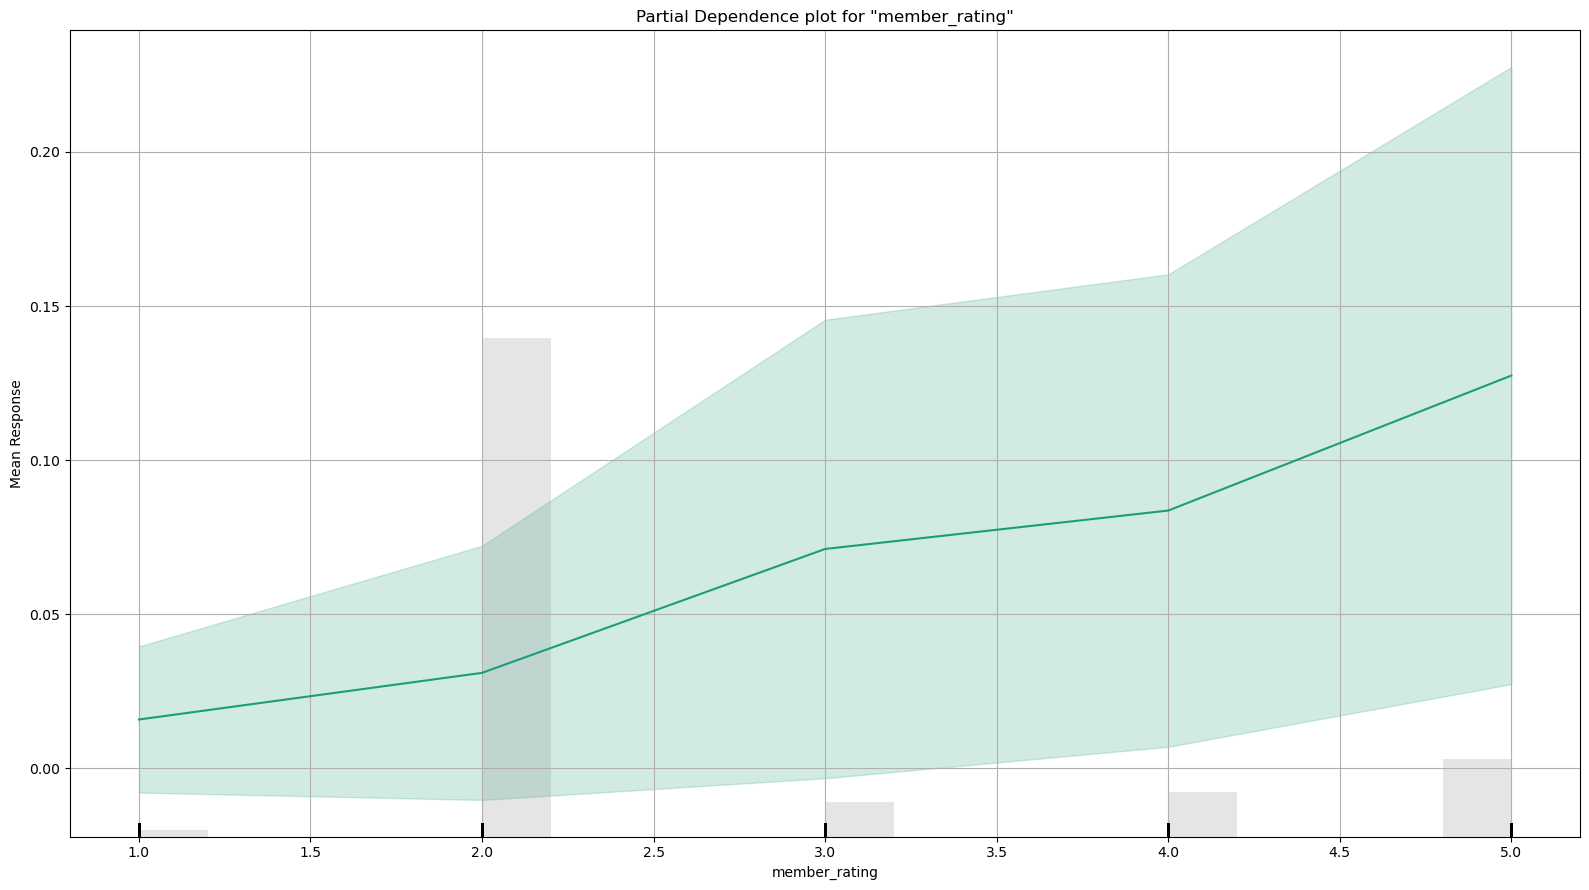

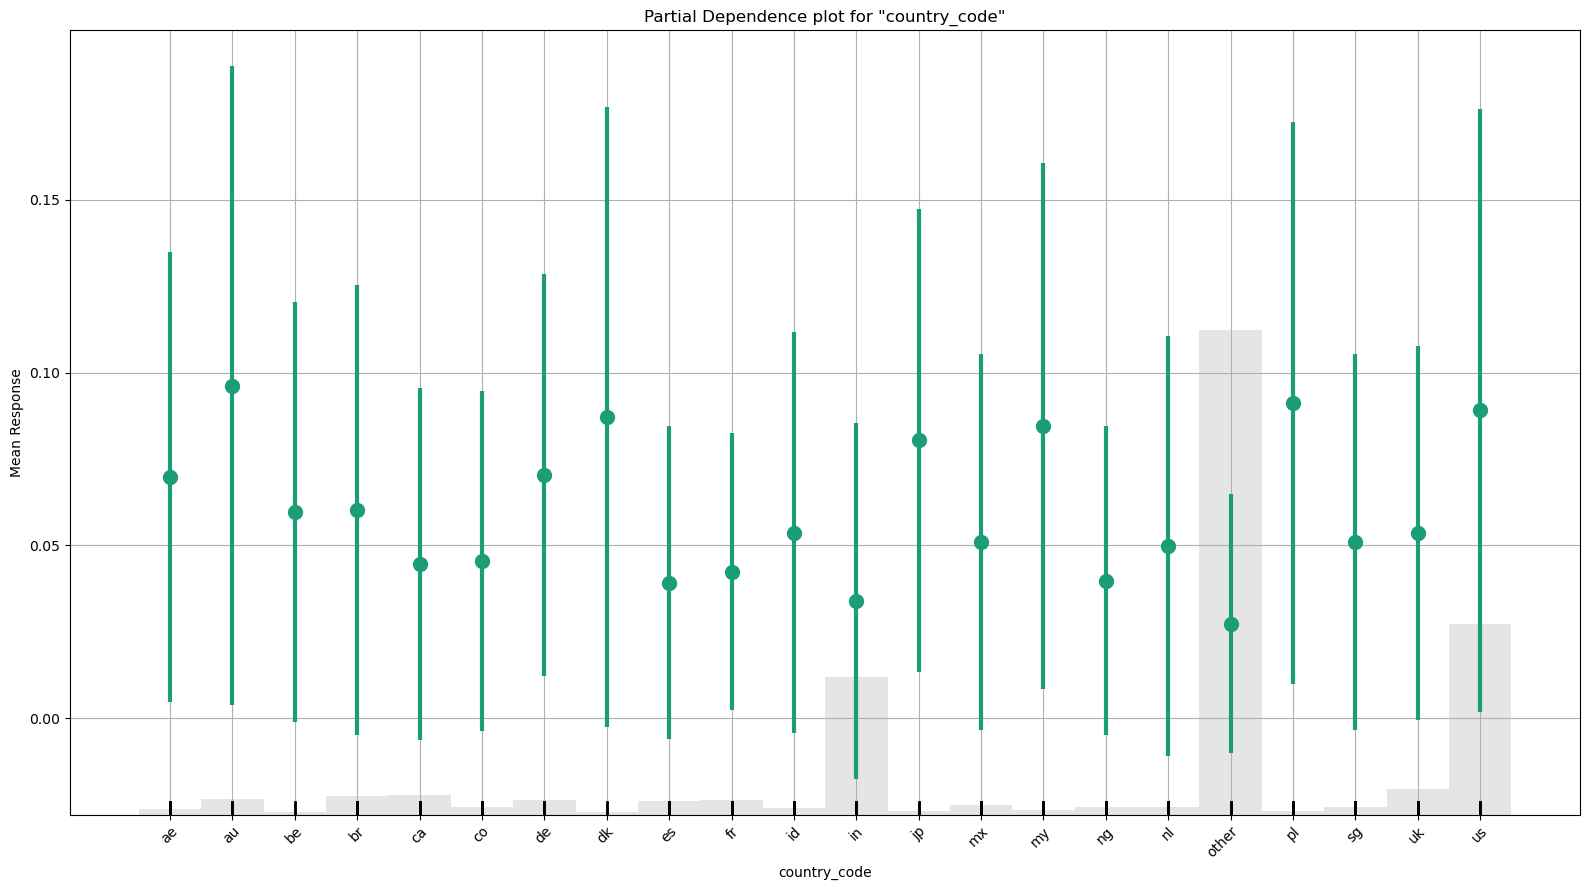

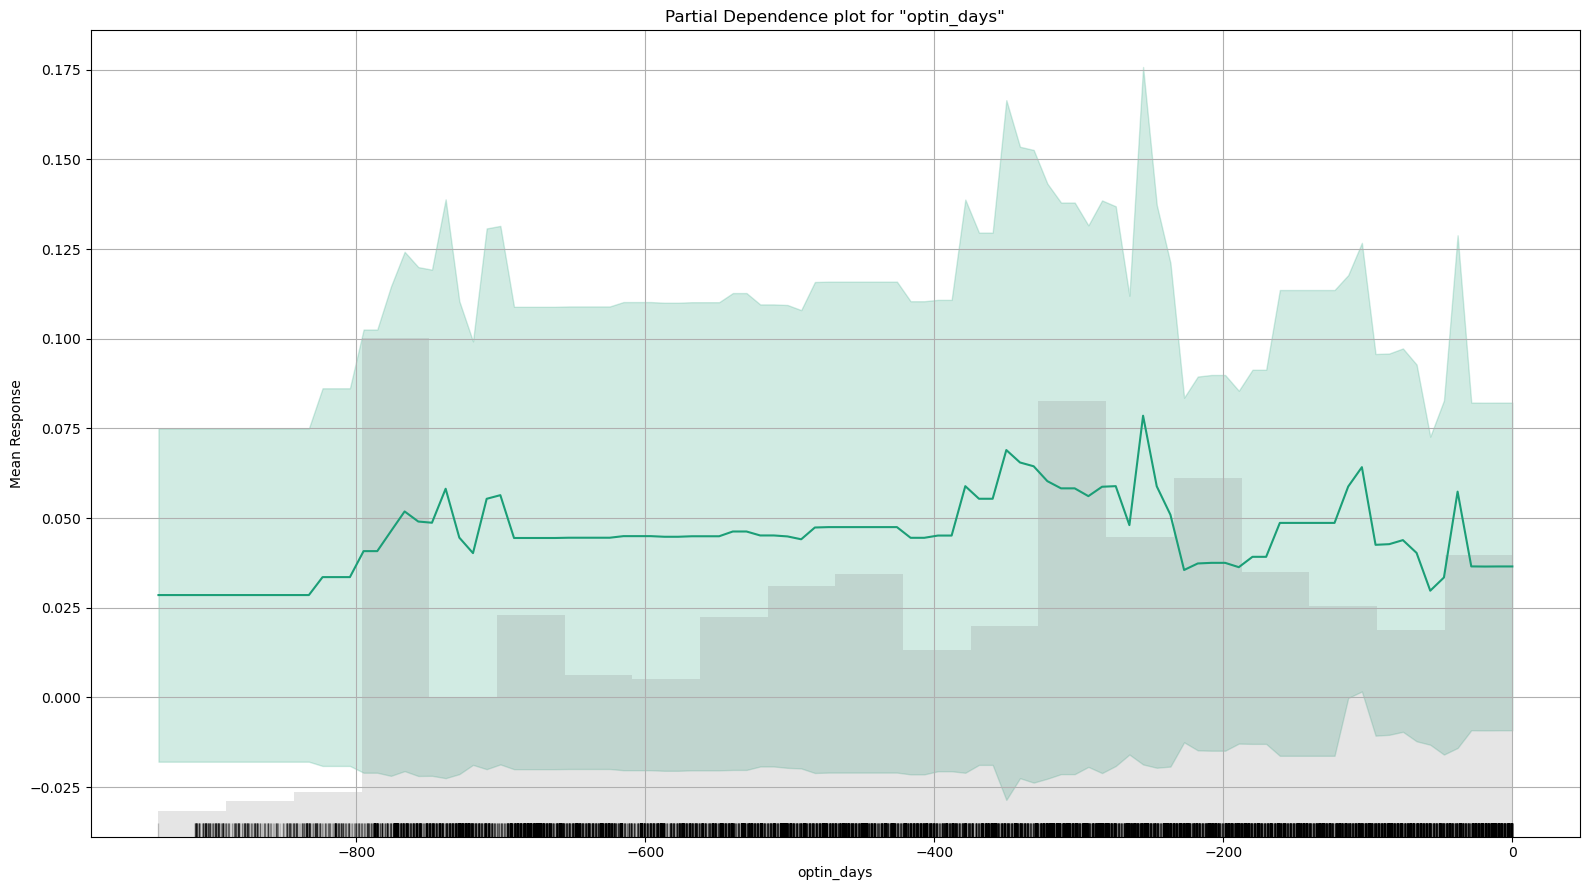

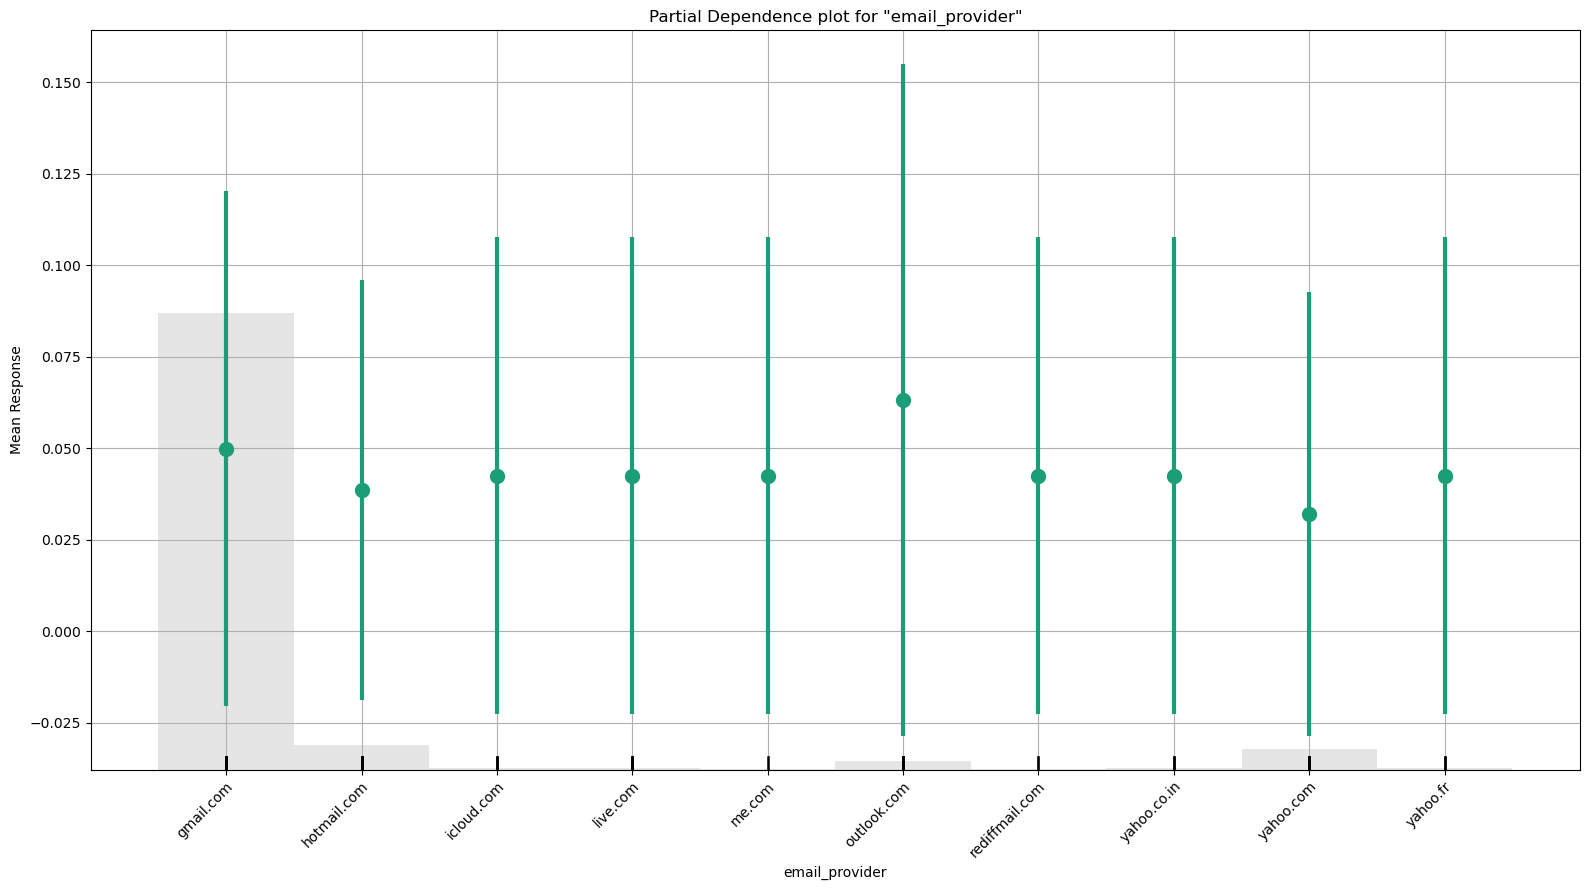

In [ ]:
best_model_h2o.explain(hf)

In [ ]:
?best_model_h2o.explain

Signature:
best_model_h2o.explain(
    frame,
    columns=None,
    top_n_features=5,
    include_explanations='ALL',
    exclude_explanations=[],
    plot_overrides={},
    figsize=(16, 9),
    render=True,
    qualitative_colormap='Dark2',
    sequential_colormap='RdYlBu_r',
    background_frame=None,
)
Docstring:
Generate model explanations on frame data set.

The H2O Explainability Interface is a convenient wrapper to a number of explainabilty
methods and visualizations in H2O.  The function can be applied to a single model or group
of models and returns an object containing explanations, such as a partial dependence plot
or a variable importance plot.  Most of the explanations are visual (plots).
These plots can also be created by individual utility functions/methods as well.

:param models: a list of H2O models, an H2O AutoML instance, or an H2OFrame with a 'model_id' column (e.g. H2OAutoML leaderboard).
:param frame: H2OFrame.
:param columns: either a list of columns or column i

In [ ]:
predictions_df = best_model_h2o.predict(hf).as_data_frame()

xgboost prediction progress: |███████████████████████████████████████████████████| (done) 100%


In [ ]:
predictions_df

,predict,p0,p1
0,0,0.966912,0.033088
1,0,0.855837,0.144163
2,0,0.972288,0.027712
3,0,0.966377,0.033623
4,0,0.986628,0.013372
...,...,...,...
19914,0,0.983641,0.016359
19915,0,0.986909,0.013091
19916,0,0.985164,0.014836
19917,0,0.984795,0.015205


In [ ]:
conn.close()
h2o.shutdown(prompt=False)

H2O session _sid_a1ee closed.
